# 03 - Five-effect and per-operand analysis (paper Fig 5, 6, Section 5.2.2)

One-digit multiplications/additions involving the operand 5 are answered
faster than the size effect alone predicts. Also reproduces the per-operand
RT curve (mean RT for each operand value 1-9, excluding 5) and compares a
linear vs logarithmic fit.


In [1]:
# Data source toggle. The live backend DB has zero trial_results as of
# 2026-09 (see ../DATA_GAPS.md) -- this app just went public. Flip
# USE_SYNTHETIC to False once real rows exist; every cell below is written
# against the DataFrame shape returned by moravec_analysis.data, so nothing
# else needs to change.
USE_SYNTHETIC = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from moravec_analysis.data import load_trial_results
from moravec_analysis.features import add_all_derived_fields, filter_rt_outliers
from moravec_analysis.synth import generate_synthetic_trials

if USE_SYNTHETIC:
    raw = generate_synthetic_trials(n_users=400, trials_per_user=150, seed=7)
else:
    raw = load_trial_results()  # defaults to apps/backend/data/moravec.sqlite

df = add_all_derived_fields(raw)
print(f"{len(df):,} trials, {df.email_hash.nunique():,} users")
df.head()


229 trials, 1 users


,id,email_hash,level_number,category_codename,operands,answer,correct,time_exceeded,time_taken,played_at,...,has_five,op1_gt_op2,unordered_pair,presented_pair,is_rhyme_pair,presented_in_rhyme_order,is_rhyme_control_pair,presented_in_control_order,table_distance_1,numeric_distance_le_2
0,b71489e4-4089-48fb-91c8-57018effab49,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[5, 3]",8,True,False,1376,2026-09-02 14:20:30.456,...,True,True,"(3, 5)","(5, 3)",False,False,True,False,<NA>,<NA>
1,ff1c2b76-e8c9-4244-81d7-0bc393f456fa,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[4, 6]",10,True,False,1384,2026-09-02 14:20:31.840,...,False,False,"(4, 6)","(4, 6)",True,False,False,False,<NA>,<NA>
2,e69af72d-ab35-434f-8cc6-083e1554cd64,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[8, 5]",13,True,False,1581,2026-09-02 14:20:33.421,...,True,True,"(5, 8)","(8, 5)",False,False,False,False,<NA>,<NA>
3,e027f4db-5f97-4e4c-af89-ee8028b725cf,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[9, 4]",36,True,False,2145,2026-09-02 14:20:35.566,...,False,True,"(4, 9)","(9, 4)",False,False,False,False,<NA>,<NA>
4,12772bbc-689d-4107-bb36-0092ee87088a,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[7, 7]",49,True,False,1259,2026-09-02 14:20:36.825,...,False,False,"(7, 7)","(7, 7)",False,False,False,False,<NA>,<NA>


In [2]:
one_by_one = df[df["category_codename"].isin(["1d+1d", "1dx1d"]) & df["correct"]]
clean = filter_rt_outliers(one_by_one, group_col="category_codename", sd=4.0)


## Mixed-effects test for the five-effect

In [3]:
import statsmodels.formula.api as smf

def fit_five_effect(data, category):
    sub = data[data["category_codename"] == category].copy()
    sub["has_five"] = sub["has_five"].astype(int)
    model = smf.mixedlm(
        "time_taken ~ product + has_five",
        data=sub,
        groups=sub["email_hash"],
    )
    return model.fit(reml=False)


for category, label in [("1d+1d", "Addition"), ("1dx1d", "Multiplication")]:
    result = fit_five_effect(clean, category)
    print(f"=== {label} ===")
    print(result.summary().tables[1].loc[["has_five"]])
    print()


/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:589: SingularMatrix

=== Addition ===
           Coef. Std.Err.      z  P>|z|    [0.025   0.975]
has_five  24.325  220.911  0.110  0.912  -408.652  457.302

=== Multiplication ===
             Coef. Std.Err.       z  P>|z|    [0.025    0.975]
has_five  -526.715  157.454  -3.345  0.001  -835.319  -218.112



/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_483525/3081543146.py:11: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  return model.fit(reml=False)
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_483525/3081543146.py:11: ConvergenceWarning: Retrying MixedLM optimization with cg
  return model.fit(reml=False)
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/

## Per-operand RT curve, operand 5 excluded (paper Fig 5/6)

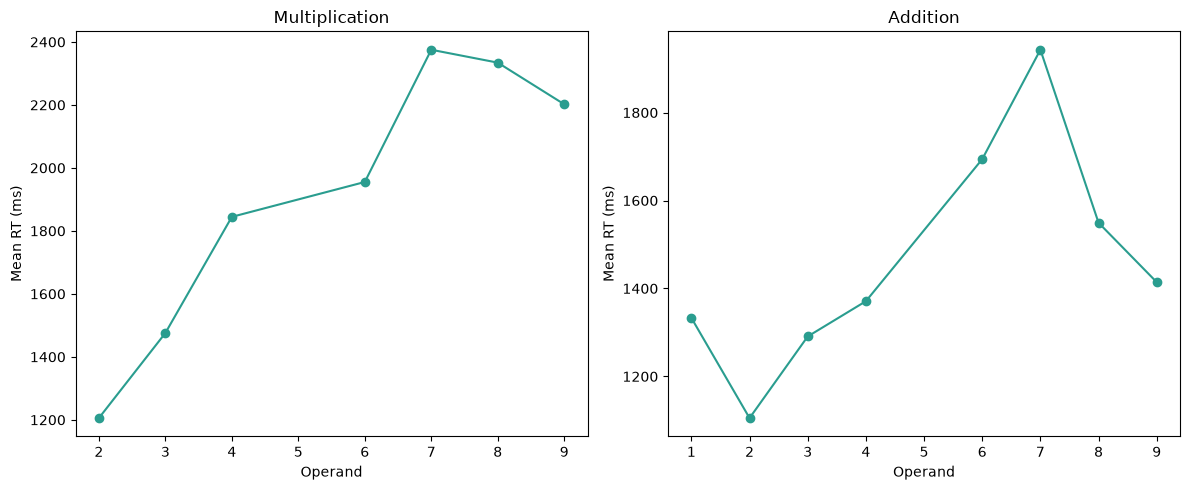

In [4]:
def per_operand_rt(data, category):
    sub = data[(data["category_codename"] == category) & (data["op1"] != 5) & (data["op2"] != 5)]
    long = pd.concat([sub[["op1", "time_taken"]].rename(columns={"op1": "operand"}),
                       sub[["op2", "time_taken"]].rename(columns={"op2": "operand"})])
    return long.groupby("operand")["time_taken"].mean()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, category, label in [(axes[0], "1dx1d", "Multiplication"), (axes[1], "1d+1d", "Addition")]:
    means = per_operand_rt(clean, category)
    ax.plot(means.index, means.values, "o-", color="#2a9d8f")
    ax.set_xlabel("Operand")
    ax.set_ylabel("Mean RT (ms)")
    ax.set_title(label)
plt.tight_layout()
plt.show()


In [5]:
from scipy.stats import pearsonr

def r2_linear_vs_log(data, category):
    means = per_operand_rt(data, category)
    x = means.index.values.astype(float)
    y = means.values
    r_lin, _ = pearsonr(x, y)
    r_log, _ = pearsonr(np.log(x), y)
    return {"category": category, "R2_linear": r_lin**2, "R2_log": r_log**2}


pd.DataFrame([
    r2_linear_vs_log(clean, "1dx1d"),
    r2_linear_vs_log(clean, "1d+1d"),
])


,category,R2_linear,R2_log
0,1dx1d,0.850663,0.920572
1,1d+1d,0.377342,0.378903


Paper reports R2 = 0.98 (log) vs 0.91 (linear) for multiplication, and 0.98 vs 0.93 for addition -- with only 8-9 points per curve (one per operand value), these R2 values are noisy on small synthetic samples; expect them to stabilize once there's enough real data per operand.